# SALES PREDICTION USING MACHINE LEARNING

## Loading Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Loading Data

In [2]:
data = pd.read_csv("Advertising.csv")
data = data.drop(columns=["Unnamed: 0"])
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## Data Exploring

In [3]:
data.shape

(200, 4)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [5]:
data.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


## Data Cleaning

In [6]:
data.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
data.dtypes

TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

## Data Visualization

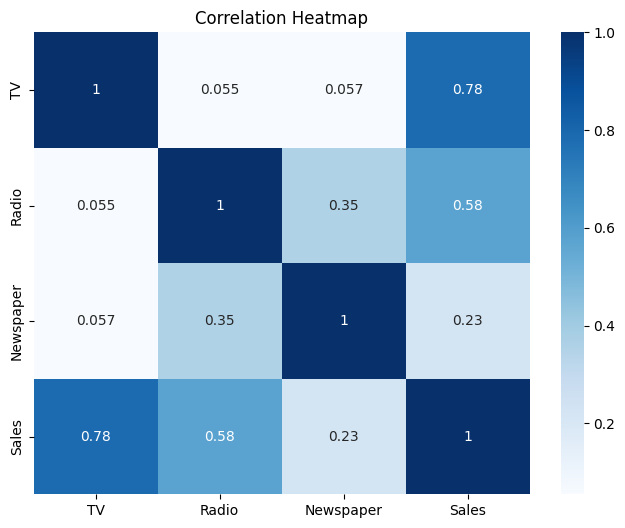

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(),annot= True, cmap = "Blues")
plt.title("Correlation Heatmap")
plt.show()

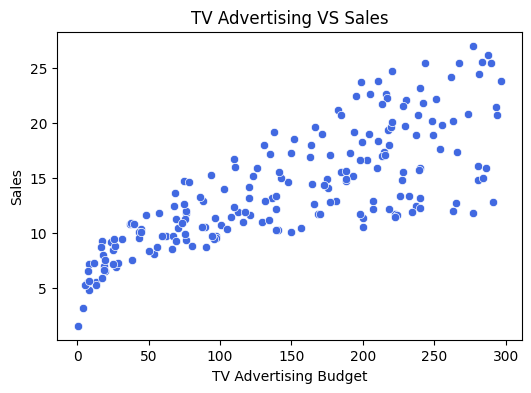

In [10]:
plt.figure(figsize=(6,4))
sns.scatterplot(x= data['TV'],y= data['Sales'],color='royalblue')
plt.title("TV Advertising VS Sales")
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.show()

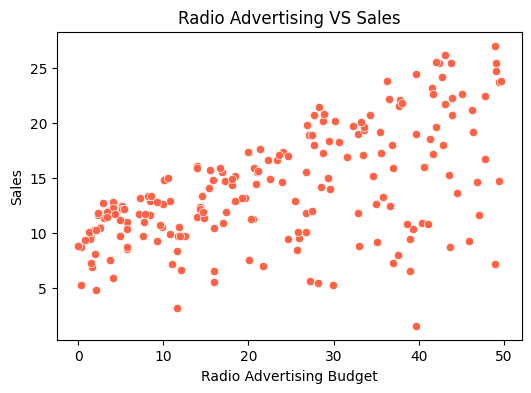

In [11]:
plt.figure(figsize=(6,4))
sns.scatterplot(x= data['Radio'],y= data['Sales'],color='tomato')
plt.title("Radio Advertising VS Sales")
plt.xlabel("Radio Advertising Budget")
plt.ylabel("Sales")
plt.show()

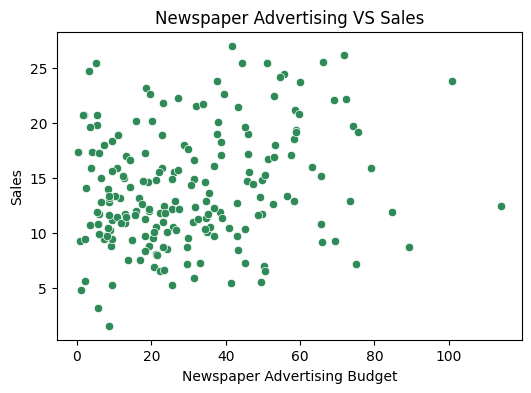

In [12]:
plt.figure(figsize=(6,4))
sns.scatterplot(x= data['Newspaper'],y= data['Sales'],color='seagreen')
plt.title("Newspaper Advertising VS Sales")
plt.xlabel("Newspaper Advertising Budget")
plt.ylabel("Sales")
plt.show()

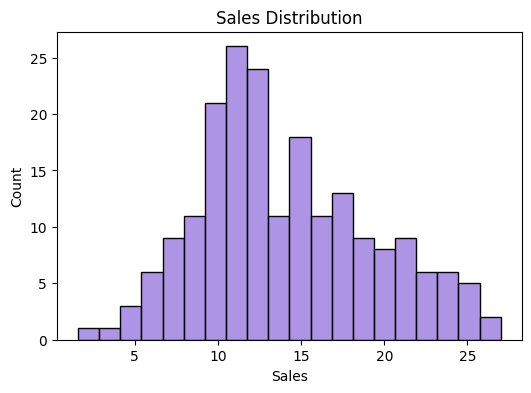

In [13]:
plt.figure(figsize=(6,4))
sns.histplot(data['Sales'], bins=20,color='mediumpurple')
plt.title("Sales Distribution")
plt.show()

## Model Training

In [14]:
x = data[['TV', 'Radio', 'Newspaper']]
y = data['Sales']

In [15]:
X_train, X_test, y_train, y_test =train_test_split(x,y,test_size=0.2,random_state=42)

In [16]:
X_train.shape

(160, 3)

In [17]:
X_test.shape

(40, 3)

In [18]:
model = LinearRegression()

In [19]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Model Testing

In [20]:
y_pred = model.predict(X_test)

In [21]:
comparison = pd.DataFrame({"Actual_Sales": y_test.values, "Predicted_Sales": y_pred})
comparison.head()

,Actual_Sales,Predicted_Sales
0,16.9,16.408024
1,22.4,20.889882
2,21.4,21.553843
3,7.3,10.608503
4,24.7,22.112373


## Model Evaluation

In [22]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

In [23]:
print("Mean Absolute Error:", mae)
print("Mean Squared Error",mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score",r2)

Mean Absolute Error: 1.4607567168117603
Mean Squared Error 3.1740973539761033
Root Mean Squared Error: 1.78159966153345
R2 Score 0.899438024100912


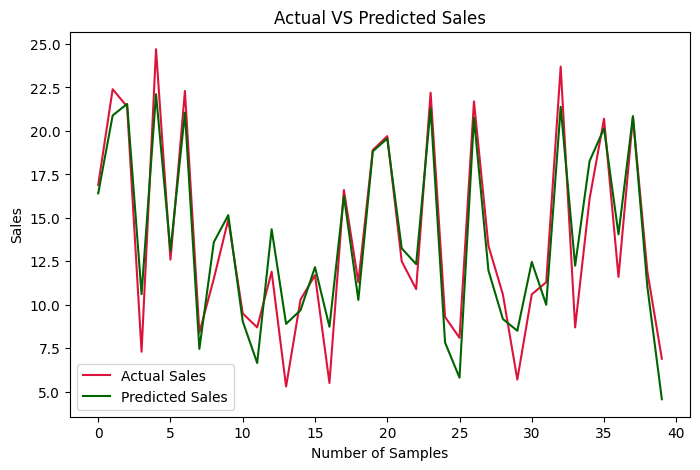

In [24]:
plt.figure(figsize= (8,5))
plt.plot(y_test.values,label="Actual Sales",color='crimson')
plt.plot(y_pred, label="Predicted Sales",color='darkgreen')

plt.title("Actual VS Predicted Sales")
plt.xlabel("Number of Samples")
plt.ylabel("Sales")
plt.legend()
plt.show()

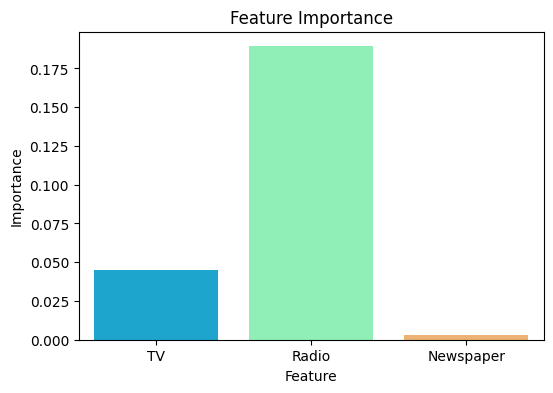

In [25]:
importance = pd.DataFrame({'Feature': x.columns,'Importance': model.coef_})
plt.figure(figsize=(6,4))
sns.barplot(x='Feature',y= 'Importance',data= importance, hue = 'Feature', palette = "rainbow")
plt.title("Feature Importance")
plt.show()

## Prediction on new Data 

In [26]:
new_data = pd.DataFrame({'TV':[230],'Radio':[35],'Newspaper':[60]})
prediction = model.predict(new_data)
print("Predicted Sales for New Data :",prediction[0])

Predicted Sales for New Data : 20.054350114612593
